In [8]:
2*4

8

In [2]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras

from tensorflow.keras import layers, models


2025-12-02 22:36:29.148434: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-02 22:36:29.148709: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-02 22:36:29.150032: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-02 22:36:29.159364: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-02 22:36:30.656933: W tensorflow/compiler/tf2

In [3]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer
from models.models import CreateModel # Conv2D model

pi = 3.14159265359

maxval=1e9
minval=1e-9

In [4]:
base = "/work/projects/SmartPixML/preamp_response/TrainedModels/model-c6103ed3-checkpoints/checkpoints"
os.listdir(base)

['weights.817-t-18437.62-v-18327.57.hdf5',
 'weights.92-t-11400.78-v-10902.14.hdf5',
 'weights.09-t1897.34-v1790.12.hdf5',
 'weights.339-t-17357.90-v-18261.01.hdf5',
 'weights.1000-t-19335.29-v-18698.33.hdf5',
 'weights.543-t-18350.72-v-18128.13.hdf5',
 'weights.705-t-19519.53-v-19530.00.hdf5',
 'weights.973-t-20071.62-v-18480.39.hdf5',
 'weights.927-t-19543.68-v-20409.91.hdf5',
 'weights.939-t-19264.01-v-18045.58.hdf5',
 'weights.499-t-18450.55-v-18663.49.hdf5',
 'weights.25-t-2890.22-v-2930.29.hdf5',
 'weights.805-t-19326.54-v-19341.98.hdf5',
 'weights.541-t-18437.83-v-17538.08.hdf5',
 'weights.19-t-222.65-v-674.13.hdf5',
 'weights.580-t-19667.36-v-18905.91.hdf5',
 'weights.483-t-18893.79-v-17567.19.hdf5',
 'weights.353-t-18062.06-v-18292.53.hdf5',
 'weights.723-t-19888.81-v-19816.17.hdf5',
 'weights.370-t-17777.10-v-18919.32.hdf5',
 'weights.856-t-19137.39-v-19285.80.hdf5',
 'weights.951-t-19389.61-v-18767.23.hdf5',
 'weights.837-t-19077.49-v-18829.21.hdf5',
 'weights.436-t-18988.50

In [5]:
# base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-{fingerprint}-checkpoints'
base_dir = "/work/projects/SmartPixML/preamp_response/TrainedModels/model-c6103ed3-checkpoints/"

plot_dir = os.path.join(base_dir, 'plots')
checkpoints_dir = os.path.join(base_dir, 'checkpoints')
training_cp_path = os.path.join(base_dir, 'training_log.csv')
training_history = pd.read_csv(training_cp_path)

os.makedirs(plot_dir, exist_ok=True)

checkpoint_files = sorted([os.path.join(checkpoints_dir, f) for f in os.listdir(checkpoints_dir) if f.endswith('.hdf5')])
checkpoint_files

['/work/projects/SmartPixML/preamp_response/TrainedModels/model-c6103ed3-checkpoints/checkpoints/weights.01-t42945.03-v14258.13.hdf5',
 '/work/projects/SmartPixML/preamp_response/TrainedModels/model-c6103ed3-checkpoints/checkpoints/weights.02-t11570.54-v10058.95.hdf5',
 '/work/projects/SmartPixML/preamp_response/TrainedModels/model-c6103ed3-checkpoints/checkpoints/weights.03-t8895.49-v7737.24.hdf5',
 '/work/projects/SmartPixML/preamp_response/TrainedModels/model-c6103ed3-checkpoints/checkpoints/weights.04-t6025.32-v5006.66.hdf5',
 '/work/projects/SmartPixML/preamp_response/TrainedModels/model-c6103ed3-checkpoints/checkpoints/weights.05-t4120.05-v3848.45.hdf5',
 '/work/projects/SmartPixML/preamp_response/TrainedModels/model-c6103ed3-checkpoints/checkpoints/weights.06-t3108.98-v3143.03.hdf5',
 '/work/projects/SmartPixML/preamp_response/TrainedModels/model-c6103ed3-checkpoints/checkpoints/weights.07-t2401.66-v2615.65.hdf5',
 '/work/projects/SmartPixML/preamp_response/TrainedModels/model-c

In [6]:
model=CreateModel(shape = (13,21,2), output = 14, n_filters=5,pool_size=3)
model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

model.summary()

2025-12-02 22:36:48.113962: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1209 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB MIG 1g.5gb, pci bus id: 0000:81:00.0, compute capability: 8.0
2025-12-02 22:36:48.274090: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 13, 21, 2)]       0         
                                                                 
 q_separable_conv2d (QSepar  (None, 11, 19, 5)         33        
 ableConv2D)                                                     
                                                                 
 q_activation (QActivation)  (None, 11, 19, 5)         0         
                                                                 
 q_conv2d (QConv2D)          (None, 11, 19, 5)         30        
                                                                 
 q_activation_1 (QActivatio  (None, 11, 19, 5)         0         
 n)                                                              
                                                                 
 average_pooling2d (Average  (None, 3, 6, 5)           0     

In [7]:
def extract_val_metric(fname):
    try:
        val_str = fname.split("-v-")[-1].replace(".hdf5", "")
        return float(val_str)
    except Exception:
        return float("-inf")

best_ckpt = None
best_val = float("-inf")

for f in checkpoint_files:
    val = extract_val_metric(os.path.basename(f))
    if val > best_val:
        best_val = val
        best_ckpt = f

print(f"Loading model from {best_ckpt}")
model.load_weights(best_ckpt)

Loading model from /work/projects/SmartPixML/preamp_response/TrainedModels/model-c6103ed3-checkpoints/checkpoints/weights.689-t-19876.69-v-20904.02.hdf5


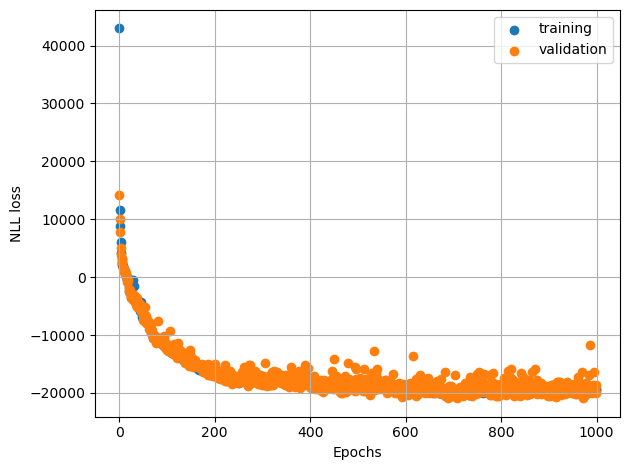

In [8]:
plt.scatter(training_history['epoch'], training_history['loss'])
plt.scatter(training_history['epoch'], training_history['val_loss'])
plt.legend(['training', 'validation'])
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('NLL loss')
plt.tight_layout() 

plt.savefig(os.path.join(base_dir,'training_hist.png'))
plt.show()

In [9]:
# dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"

# NOISE_MU = 0.0
# NOISE_SIGMA = 400.0 # e-

# tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig")
# tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
# tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")


In [10]:
# dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/contained"
#dataset_base_dir = '/depot/cms/users/das214/datasets/temporary/preamp_response/'
#tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t")
#dataset_train_dir = os.path.join(dataset_base_dir, "train")
#dataset_test_dir = os.path.join(dataset_base_dir, "test")
#tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
#tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

#batch_size = 5000
#val_batch_size = 5000
#train_file_size = len(os.listdir(dataset_train_dir))
#val_file_size = len(os.listdir(dataset_test_dir))




dataset_base_dir = '/work/projects/SmartPixML/preamp_response/'
tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t")

dataset_train_dir = os.path.join(dataset_base_dir, "train")
dataset_test_dir = os.path.join(dataset_base_dir, "test")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

batch_size = 5000
val_batch_size = 5000
train_file_size = len(os.listdir(dataset_train_dir))
val_file_size = len(os.listdir(dataset_test_dir))

In [11]:
test_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=True,
)
labels_scale = test_generator.labels_scale
print(labels_scale)

Loading metadata from /work/projects/SmartPixML/preamp_response/TFR_files/2t/TFR_val/metadata.json
[74.35833351 18.61257416  8.58538849  0.35536798]


In [12]:
# predicts test data
p_test = model.predict(test_generator)

 3/16 [====>.........................] - ETA: 1s

2025-12-02 22:36:57.004109: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


16/16 [==============================] - 2s 116ms/step


In [13]:
complete_truth = None
for _, y in tqdm(test_generator):
        if complete_truth is None:
            complete_truth = y
        else:
            complete_truth = np.concatenate((complete_truth, y), axis=0)

100%|██████████| 16/16 [00:01<00:00, 13.79it/s]


In [14]:
def softplus(x):
    x = np.asarray(x)
    return np.maximum(x, 0) + np.log1p(np.exp(-np.abs(x)))

In [15]:
# creates df with all predicted values and matrix elements - 4 predictions, all 10 unique matrix elements
df = pd.DataFrame(p_test,columns=['x','M11','y','M22','cotA','M33','cotB','M44','M21','M31','M32','M41','M42','M43'])

# stores all true values in same matrix as xtrue, ytrue, etc.
df['xtrue'] = complete_truth[:,0]
df['ytrue'] = complete_truth[:,1]
df['cotAtrue'] = complete_truth[:,2]
df['cotBtrue'] = complete_truth[:,3]
df['M11'] = minval+tf.math.maximum(df['M11'], 0)
df['M22'] = minval+tf.math.maximum(df['M22'], 0)
df['M33'] = minval+tf.math.maximum(df['M33'], 0)
df['M44'] = minval+tf.math.maximum(df['M44'], 0)

df['sigmax'] = abs(df['M11'])
df['sigmay'] = np.sqrt(df['M21']**2 + df['M22']**2)
df['sigmacotA'] = np.sqrt(df['M31']**2+df['M32']**2+df['M33']**2)
df['sigmacotB'] = np.sqrt(df['M41']**2+df['M42']**2+df['M43']**2+df['M44']**2)

# calculates residuals for x, y, cotA, cotB
residuals = df['xtrue'] - df['x']
residualsy = df['ytrue'] - df['y']
residualsA = df['cotAtrue'] - df['cotA']
residualsB = df['cotBtrue'] - df['cotB']

# stores results as csv
df.to_csv("test_4x4.csv",header=True,index=False)
df.to_parquet(os.path.join(dataset_base_dir, "2t_Conv2D_preamp_response.parquet"))



In [17]:
df7= pd.read_parquet(os.path.join(dataset_base_dir, "2t_Conv2D_preamp_response.parquet"))
df7.head()

,x,M11,y,M22,cotA,M33,cotB,M44,M21,M31,...,M42,M43,xtrue,ytrue,cotAtrue,cotBtrue,sigmax,sigmay,sigmacotA,sigmacotB
0,-0.327637,0.112549,0.771240,0.100647,-0.367615,0.030212,-0.344849,0.140076,0.013489,-0.012512,...,-0.044128,0.006042,-0.129811,0.865489,-0.313227,-0.462210,0.112549,0.101547,0.032709,0.147571
1,-0.681091,0.137756,-0.534851,0.079590,0.444763,0.028320,0.508667,0.147156,0.040955,-0.011169,...,-0.012756,0.026428,-0.863278,-0.522394,0.468347,0.600080,0.137756,0.089509,0.031188,0.154647
2,-0.165405,0.134277,-0.393982,0.109985,-0.134583,0.031860,-0.184265,0.209900,0.014709,-0.002686,...,-0.039185,0.022034,-0.291459,-0.450217,-0.106681,-0.201220,0.134277,0.110965,0.031974,0.214660
3,0.202637,0.237000,-0.863770,0.047974,-0.906250,0.041199,0.295166,0.128723,-0.026367,-0.021423,...,-0.043274,-0.007446,0.181220,-0.876231,-0.909648,0.435377,0.237000,0.054742,0.046457,0.144547
4,-0.804504,0.134766,-0.307251,0.064819,-0.566467,0.026428,0.249451,0.111938,-0.018982,-0.009888,...,-0.005432,-0.009583,-0.775406,-0.255981,-0.576360,0.240100,0.134766,0.067542,0.028224,0.113094


In [18]:
os.path.join(dataset_base_dir, "2t_Conv2D_preamp_response.parquet")

'/work/projects/SmartPixML/preamp_response/2t_Conv2D_preamp_response.parquet'

In [20]:
df.head()

,x,M11,y,M22,cotA,M33,cotB,M44,M21,M31,...,M42,M43,xtrue,ytrue,cotAtrue,cotBtrue,sigmax,sigmay,sigmacotA,sigmacotB
0,-0.327637,0.112549,0.771240,0.100647,-0.367615,0.030212,-0.344849,0.140076,0.013489,-0.012512,...,-0.044128,0.006042,-0.129811,0.865489,-0.313227,-0.462210,0.112549,0.101547,0.032709,0.147571
1,-0.681091,0.137756,-0.534851,0.079590,0.444763,0.028320,0.508667,0.147156,0.040955,-0.011169,...,-0.012756,0.026428,-0.863278,-0.522394,0.468347,0.600080,0.137756,0.089509,0.031188,0.154647
2,-0.165405,0.134277,-0.393982,0.109985,-0.134583,0.031860,-0.184265,0.209900,0.014709,-0.002686,...,-0.039185,0.022034,-0.291459,-0.450217,-0.106681,-0.201220,0.134277,0.110965,0.031974,0.214660
3,0.202637,0.237000,-0.863770,0.047974,-0.906250,0.041199,0.295166,0.128723,-0.026367,-0.021423,...,-0.043274,-0.007446,0.181220,-0.876231,-0.909648,0.435377,0.237000,0.054742,0.046457,0.144547
4,-0.804504,0.134766,-0.307251,0.064819,-0.566467,0.026428,0.249451,0.111938,-0.018982,-0.009888,...,-0.005432,-0.009583,-0.775406,-0.255981,-0.576360,0.240100,0.134766,0.067542,0.028224,0.113094


# residuals (mean, stdv)

In [21]:
# x
(np.mean(residuals)*labels_scale[0],np.std(residuals)*labels_scale[0])

(-0.4829829890553672, 12.466094779887658)

In [22]:
# y
(np.mean(residualsy)*labels_scale[1],np.std(residualsy)*labels_scale[1])

(0.09547238123627096, 1.8385644742828993)

In [23]:
# cotA
(np.mean(residualsA)*labels_scale[2],np.std(residualsA)*labels_scale[2])

(0.015189330006151578, 0.31839099086390554)

In [24]:
# cotB
(np.mean(residualsB)*labels_scale[3],np.std(residualsB)*labels_scale[3])

(-0.0009894823931315333, 0.06129295937810834)

# x residuals

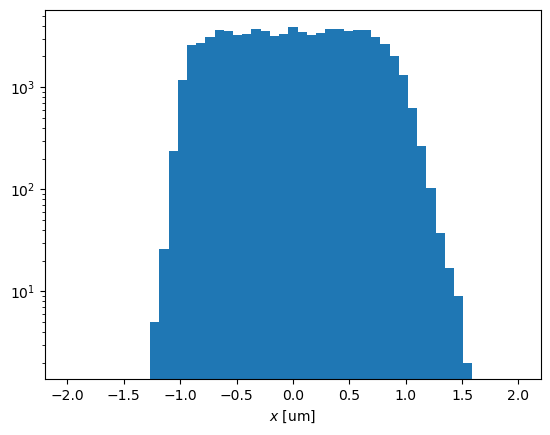

In [25]:
plt.hist(p_test[:,0],bins=np.linspace(-2,2,50))
plt.yscale('log')
plt.xlabel(r'$x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_dist.png')
plt.savefig(save_fig_path)

plt.show()

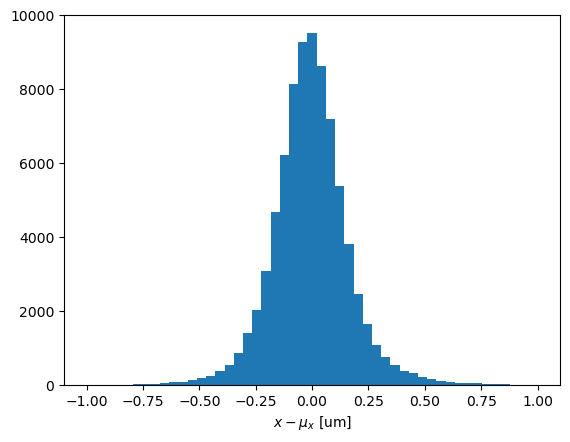

In [26]:
plt.hist(residuals,bins=np.linspace(-1,1,50))
#plt.yscale('Log')
plt.xlabel(r'$x-\mu_x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

In [27]:
2/50

0.04

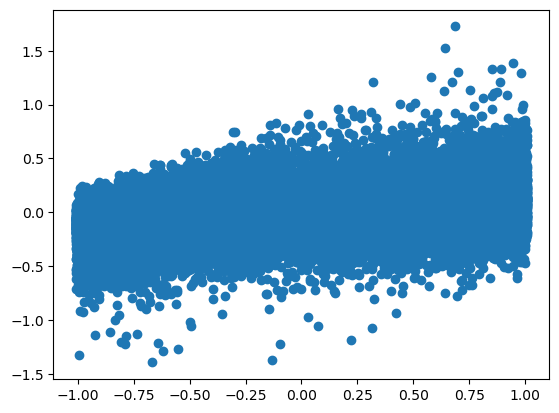

In [28]:
plt.scatter(df['xtrue'], (df['xtrue']-df['x']))
plt.show()

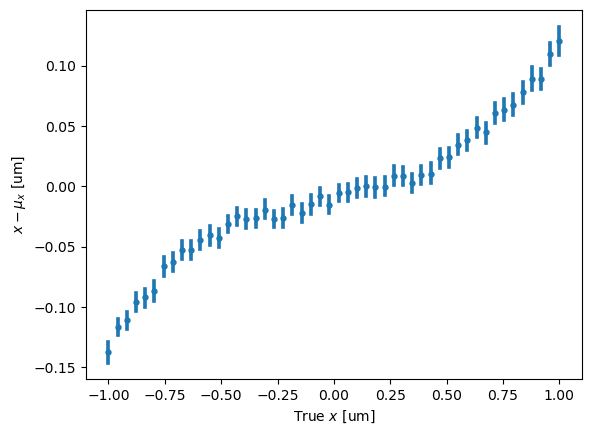

In [29]:
x = sns.regplot(x=df['xtrue'], y=(df['xtrue']-df['x']), x_bins=np.linspace(-1,1,50), fit_reg=None, marker='.')
plt.xlabel(r'True $x$ [um]')
plt.ylabel(r'$x-\mu_x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# y residuals

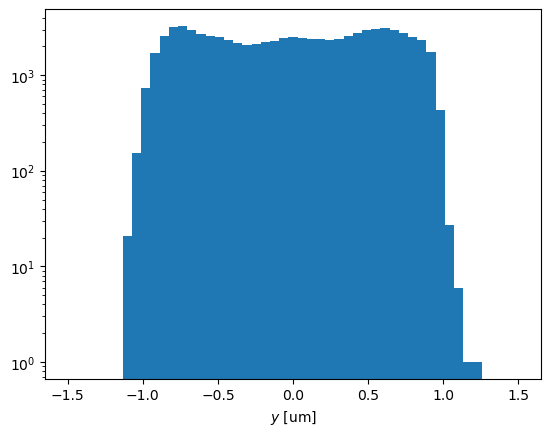

In [30]:
plt.hist(p_test[:,2],bins=np.linspace(-1.5,1.5,50))
plt.yscale('log')
plt.xlabel(r'$y$ [um]')

save_fig_path = os.path.join(plot_dir, 'y_dist.png')
plt.savefig(save_fig_path)

plt.show()

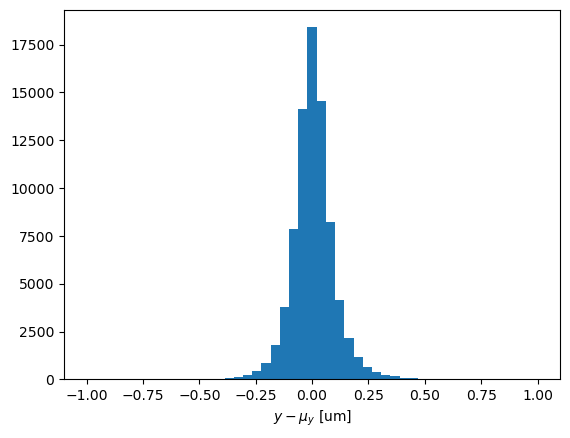

In [31]:
plt.hist(residualsy,bins=np.linspace(-1,1,50))
#plt.yscale('Log')
plt.xlabel(r'$y-\mu_y$ [um]')

save_fig_path = os.path.join(plot_dir, 'y_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

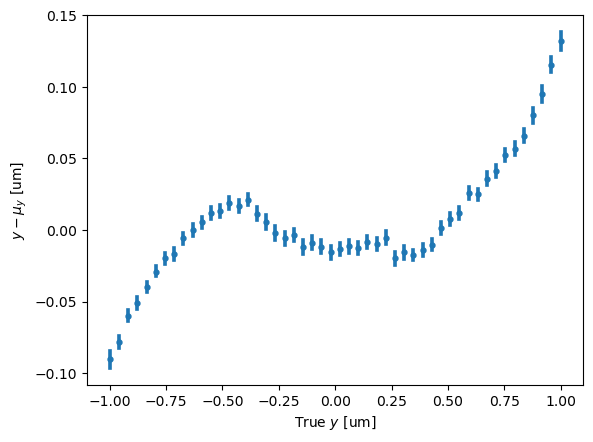

In [32]:
x = sns.regplot(x=df['ytrue'], y=(df['ytrue']-df['y']), x_bins=np.linspace(-1,1,50), fit_reg=None, marker='.')
plt.xlabel(r'True $y$ [um]')
plt.ylabel(r'$y-\mu_y$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# cotA residuals

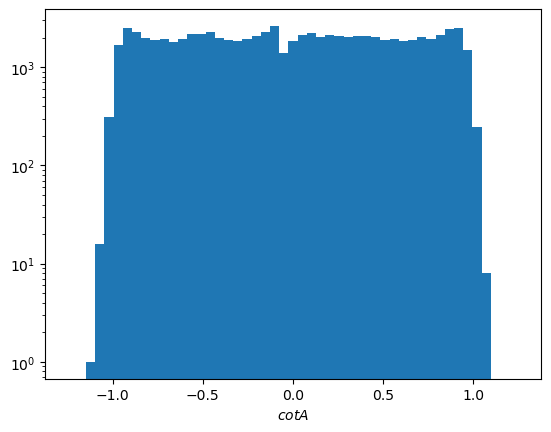

In [33]:
plt.hist(df["cotA"],bins=np.linspace(-1.25,1.25,50))
plt.yscale('log')
plt.xlabel(r'$cotA$')

save_fig_path = os.path.join(plot_dir, 'cotA_dist.png')
plt.savefig(save_fig_path)

plt.show()

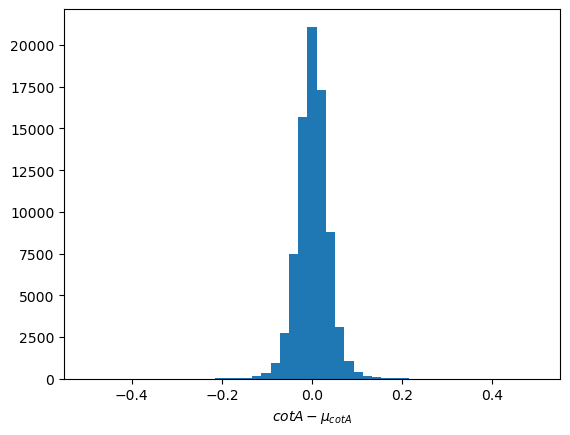

In [34]:
plt.hist(residualsA,bins=np.linspace(-0.5,0.5,50))
#plt.yscale('Log')
plt.xlabel(r'$cotA-\mu_{cotA}$')

save_fig_path = os.path.join(plot_dir, 'cotA_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

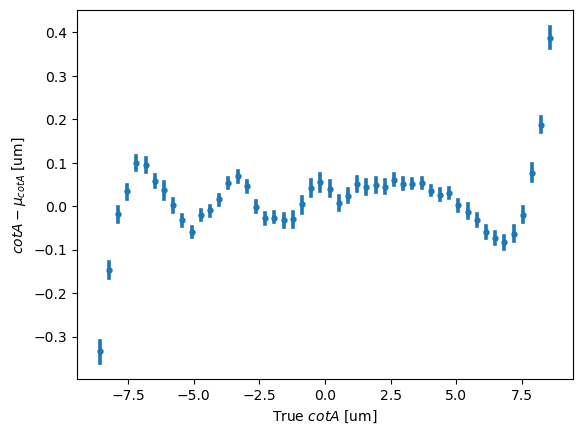

In [35]:
x = sns.regplot(x=df['cotAtrue']*labels_scale[2], y=(df['cotAtrue']-df['cotA'])*labels_scale[2], x_bins=np.linspace(-labels_scale[2],labels_scale[2],50), fit_reg=None, marker='.')
plt.xlabel(r'True $cotA$ [um]')
plt.ylabel(r'$cotA-\mu_{cotA}$ [um]')

save_fig_path = os.path.join(plot_dir, 'cotA_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# cotB residuals

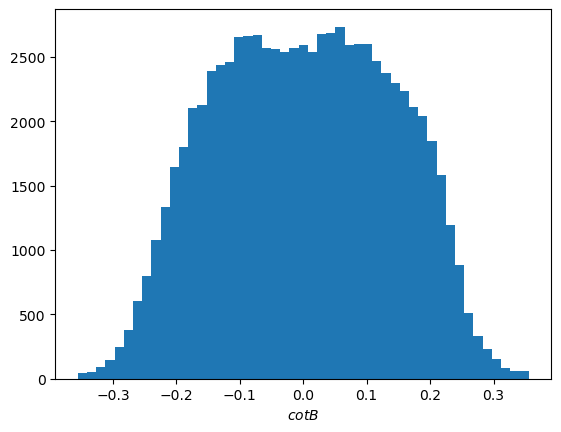

In [36]:
plt.hist(df["cotB"]*labels_scale[3],bins=np.linspace(-labels_scale[3],labels_scale[3],50))
#plt.yscale('Log')
plt.xlabel(r'$cotB$')

save_fig_path = os.path.join(plot_dir, 'cotB_dist.png')
plt.savefig(save_fig_path)

plt.show()

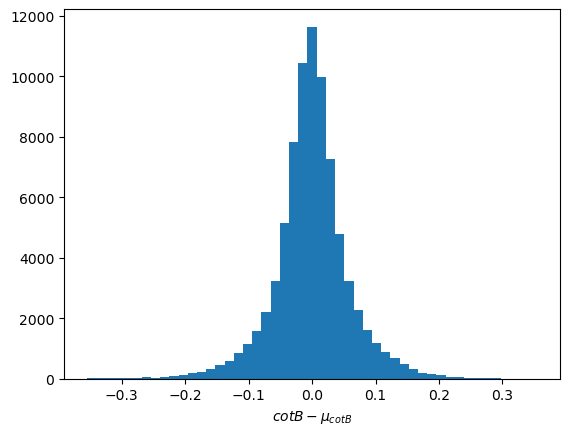

In [37]:
plt.hist(residualsB*labels_scale[3],bins=np.linspace(-labels_scale[3],labels_scale[3],50))
#plt.yscale('Log')
plt.xlabel(r'$cotB-\mu_{cotB}$')

save_fig_path = os.path.join(plot_dir, 'cotB_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

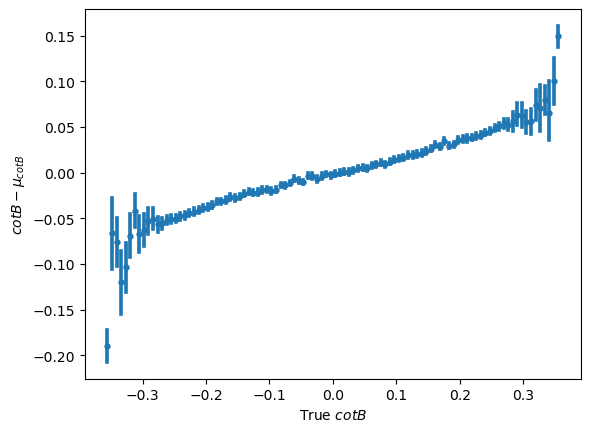

In [38]:
x = sns.regplot(x=df['cotBtrue']*labels_scale[3], y=(df['cotBtrue']-df['cotB'])*labels_scale[3], x_bins=np.linspace(-labels_scale[3],labels_scale[3],100), fit_reg=None, marker='.')
plt.xlabel(r'True $cotB$')
plt.ylabel(r'$cotB-\mu_{cotB} $')

save_fig_path = os.path.join(plot_dir, 'cotB_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# pull

In [39]:
df['pullx'] = (df['xtrue']-df['x'])/df['sigmax']
df['pully'] = (df['ytrue']-df['y'])/df['sigmay']
df['pullcotA'] = (df['cotAtrue']-df['cotA'])/df['sigmacotA']
df['pullcotB'] = (df['cotBtrue']-df['cotB'])/df['sigmacotB']

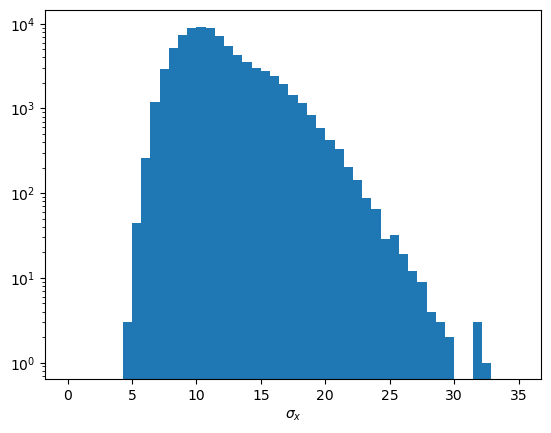

In [40]:
plt.hist(df['sigmax'] *labels_scale[0],bins=np.linspace(0,35,50))
plt.xlabel('$\sigma_{x}$')
plt.yscale('log')

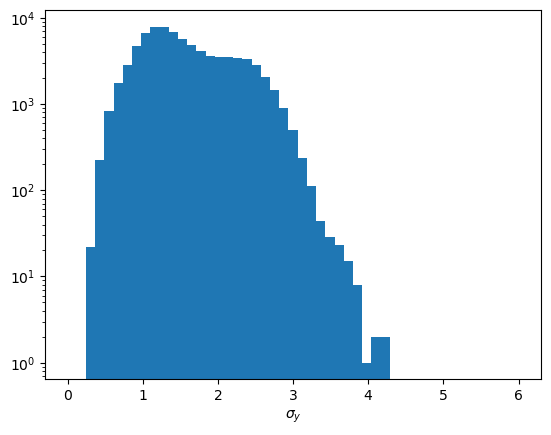

In [41]:
plt.hist(df['sigmay']*labels_scale[1],bins=np.linspace(0,6,50))
plt.xlabel('$\sigma_{y}$')
plt.yscale('log')

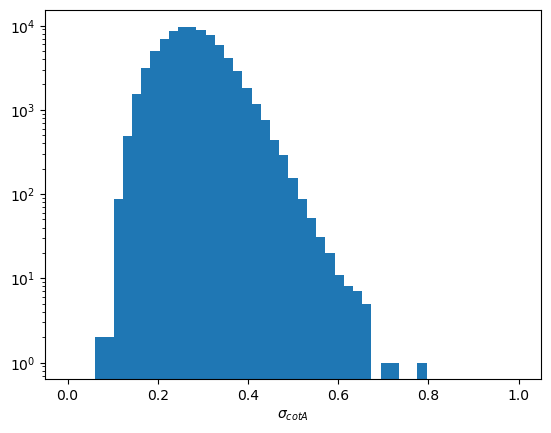

In [42]:
plt.hist(df['sigmacotA'] *labels_scale[2],bins=np.linspace(0,1.0,50))
plt.xlabel('$\sigma_{cotA}$')
plt.yscale('log')

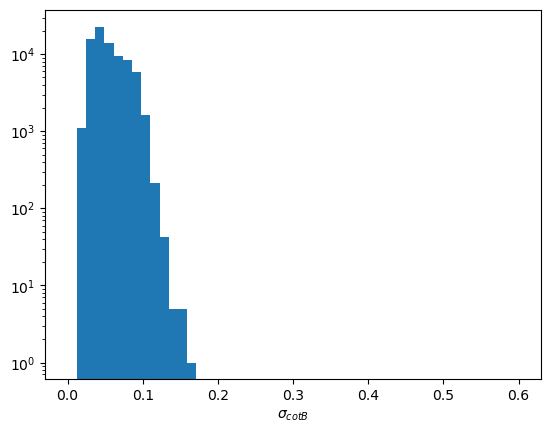

In [43]:
plt.hist(df['sigmacotB'] *labels_scale[3] ,bins=np.linspace(0,0.6,50))
plt.xlabel('$\sigma_{cotB}$')
plt.yscale('log')

In [44]:
from scipy.optimize import curve_fit

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

def pull_plot(ax, var, name):
    
    h = ax.hist(df[var],bins=np.linspace(-5,5,50),histtype='step')
    ax.set_xlabel(name)
    ax.set_yscale('log')

    ydata = h[0]
    xdata = h[1][:-1]+3/50.

    pars, cov = curve_fit(gauss,xdata,ydata)

    xbins = np.linspace(-5,5,100)
    ax.plot(xbins,gauss(xbins,pars[0],pars[1],pars[2]),color='black')
    ax.set_ylim(0.5,100000)

    print('Mean',pars[1])
    print('Sigma',pars[2])
    
    ax.text(-5,2000,"$\mu$="+str(round(pars[1],2)))
    ax.text(-5,1000,"$\sigma$="+str(round(abs(pars[2]),2)))

# Pull Plot

Mean -0.1114826862098346
Sigma 0.9227544632956935
Mean -0.00494085811683965
Sigma -0.9278556578466793
Mean 0.01984808520746733
Sigma 0.9528284691319261
Mean -0.04929982283744863
Sigma -0.8669928093908741


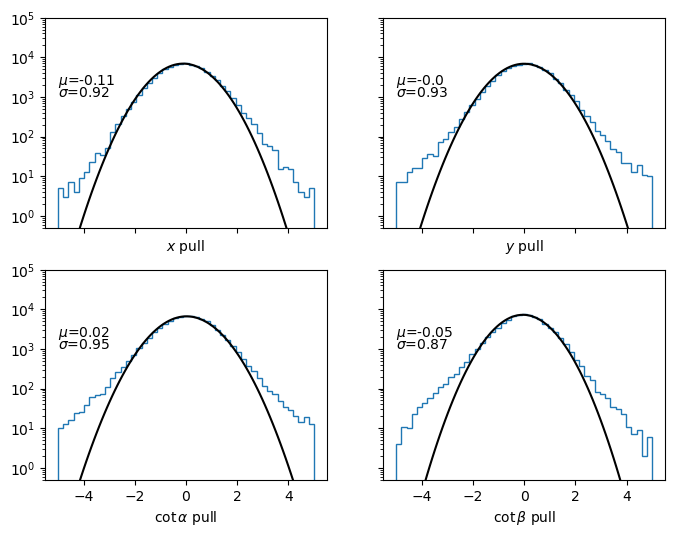

In [45]:
fig, axes = plt.subplots(2,2,sharex=True,sharey=True,figsize=(8,6))
pull_plot(axes[0][0],'pullx',r'$x$ pull')
pull_plot(axes[0][1],'pully',r'$y$ pull')
pull_plot(axes[1][0],'pullcotA',r'$\cot\alpha$ pull')
pull_plot(axes[1][1],'pullcotB',r'$\cot\beta$ pull')

save_fig_path = os.path.join(plot_dir, 'Pull.png')
plt.savefig(save_fig_path)

plt.show()

# Summary

In [46]:
def residual_plot(ax, thisdf, var1, var2, name, scaling=1.0):
    
    nbins = 15
    
    var1_scaled = thisdf[var1] * scaling
    var2_scaled = thisdf[var2] * scaling
    residual_scaled = var1_scaled - var2_scaled
    
    xmin = np.min(var1_scaled)
    xmax = np.max(var1_scaled)
    
    step = 1.0*(xmax-xmin)/nbins
    
    x = sns.regplot(x=var1_scaled, y=residual_scaled, x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    thisdf['residual'+var2] = residual_scaled
    print(var1)
    
    means = []
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
        downbar += [means[i] - np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

def inverse_cot(cota):
    a = np.arctan(1.0/cota)
    a[np.where(a<0)] = a[np.where(a<0)] + pi
    return a    

def residual_plot_deg(ax, thisdf, var1, var2, name, scaling=1.0):
    # positions
    if 'cot' not in var1:
        residual_plot(ax, thisdf, var1, var2, name, scaling=scaling)
        return

    thisdf['angle'] = inverse_cot(thisdf[var2].values * scaling)*180/pi
    
    thisdf['angleup'] = abs(inverse_cot((thisdf[var2].values + thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angledown'] = abs(inverse_cot((thisdf[var2].values - thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angletrue'] = inverse_cot(thisdf[var1].values * scaling)*180/pi
        
    var1 = 'angletrue'
    var2 = 'angle'
    
    nbins = 15
    xmin = np.min(thisdf[var1])
    xmax = np.max(thisdf[var1])
    
    step = 1.0*(xmax-xmin)/nbins
        
    x = sns.regplot(x=thisdf[var1], y=(thisdf[var1]-thisdf[var2]), x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    thisdf['residual'+var2] = (thisdf[var1]-thisdf[var2])
    print(var1)
    
    means = []    
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['angleup'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        downbar += [means[i] - np.mean(thisdf['angledown'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
    #ax.scatter(x=np.linspace(xmin,xmax,nbins),y=means)
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

# Summary Plot

xtrue
ytrue


/tmp/ipykernel_1153/2844183014.py:31: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


/tmp/ipykernel_1153/2844183014.py:31: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue


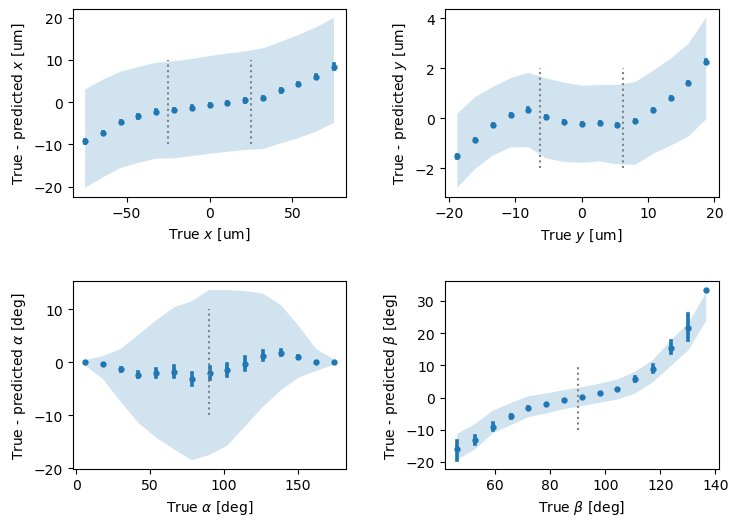

In [47]:
fig, axes = plt.subplots(2,2,figsize=(8,6))
fig.tight_layout(pad=4.0)
residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]', scaling=labels_scale[0])
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]', scaling=labels_scale[1])
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df,'cotAtrue','cotA',r'$\alpha$ [deg]', scaling=labels_scale[2])
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df,'cotBtrue','cotB',r'$\beta$ [deg]', scaling=labels_scale[3])
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')

save_fig_path = os.path.join(plot_dir, 'summary.png')
plt.savefig(save_fig_path)